# Clustering — non-social dataset

Run the following clustering algorithms on **`non_social_dataset.csv`** and assess
how well each separates the two groups defined by `success_target`:

1. K-Means
2. PAM (Partitioning Around Medoids)
3. Hierarchical Clustering (Ward)
4. Density Clustering (HDBSCAN, with OPTICS fallback)
5. DBSCAN
6. Fuzzy C-Means

For each algorithm we compute:

- **External metrics** vs `success_target`: ARI, NMI, FMI, homogeneity, completeness, V-measure
- **Internal metrics**: Silhouette, Calinski-Harabasz, Davies-Bouldin
- **Confusion matrix** between cluster labels and `success_target`
- **2D PCA projection** coloured by predicted cluster vs by true label

This dataset uses only **non-social** movie features (metadata, budget, release context, etc.). It serves as the baseline: how separable are the two success groups with no signal from the trailer audience?

A final summary table ranks all algorithms by ARI.


## 0. Optional dependencies

Some of the algorithms require packages outside the standard `scikit-learn`
distribution. Uncomment the install line below the first time you run this
notebook in a fresh environment.

In [1]:
# !pip install scikit-learn-extra scikit-fuzzy hdbscan

## 1. Imports and setup

In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, OPTICS
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    fowlkes_mallows_score,
    homogeneity_score,
    completeness_score,
    v_measure_score,
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
)
from scipy.cluster.hierarchy import linkage, dendrogram

# Optional packages
try:
    from sklearn_extra.cluster import KMedoids
    HAS_KMEDOIDS = True
except ImportError:
    HAS_KMEDOIDS = False

try:
    import skfuzzy as fuzz
    HAS_SKFUZZY = True
except ImportError:
    HAS_SKFUZZY = False

try:
    import hdbscan
    HAS_HDBSCAN = True
except ImportError:
    HAS_HDBSCAN = False

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
RANDOM_STATE = 42

print(f"KMedoids available : {HAS_KMEDOIDS}")
print(f"skfuzzy available  : {HAS_SKFUZZY}")
print(f"hdbscan available  : {HAS_HDBSCAN}")

KMedoids available : False
skfuzzy available  : True
hdbscan available  : True



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/home/vscode/.local/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/vscode/.local/lib/python3.12/site-packages/traitlets/config/application.py", line 1082, in launch_instance
    app.start()
  File "/home/vscode/.local/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/home/vscode/.local/

## 2. Load data

In [3]:
DATA_PATH = "../../data/non_social_dataset.csv"
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (452, 13)


,success_target,release_date,dow,original_language,first_production_country,first_production_company,first_genre,production_budget,opening_theaters,runtime,first_cast,first_director,trailer_count
0,0,2022-12-14,3,en,United States of America,20th Century Studios,Action,400000000,4202,192,Sam Worthington,James Cameron,6.0
1,0,2025-12-17,3,en,United States of America,20th Century Studios,Science Fiction,400000000,3800,198,Sam Worthington,James Cameron,6.0
2,0,2023-09-15,5,en,Bulgaria,Millennium Media,Action,100000000,3518,103,Jason Statham,Scott Waugh,4.0
3,0,2022-12-07,3,en,United States of America,DreamWorks Animation,Animation,110000000,4099,103,Antonio Banderas,Joel Crawford,NaN
4,0,2025-02-27,4,en,Germany,Constantin Film,Action,55000000,1370,101,Milla Jovovich,Paul W. S. Anderson,2.0


In [4]:
print("Class balance for success_target:")
print(df["success_target"].value_counts(dropna=False))
print()
print("Null counts per column (only non-zero):")
nulls = df.isna().sum()
print(nulls[nulls > 0] if (nulls > 0).any() else "no nulls")

Class balance for success_target:
success_target
0    412
1     40
Name: count, dtype: int64

Null counts per column (only non-zero):
first_production_country    16
first_production_company    18
first_genre                  5
first_cast                   4
first_director               1
trailer_count               42
dtype: int64


## 3. Preprocessing

- Target: `success_target` (kept aside as `y`)
- Drop `release_date` (the day-of-week `dow` already captures the seasonal signal)
- Drop high-cardinality categorical columns (`first_cast`, `first_director`,
  `first_production_company`) — they'd explode the feature space after one-hot
  encoding and dominate distances with mostly-zero columns
- Numeric columns → median impute + standard scale
- Remaining categoricals → most-frequent impute + one-hot


In [5]:
y = df["success_target"].astype(int).values

drop_cols = [
    "success_target",
    "release_date",
    "first_cast",
    "first_director",
    "first_production_company",
]
X_raw = df.drop(columns=drop_cols)

numeric_cols = X_raw.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X_raw.select_dtypes(include=["object"]).columns.tolist()
print("Numeric features    :", numeric_cols)
print("Categorical features:", categorical_cols)

preprocess = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), numeric_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]), categorical_cols),
])

X = preprocess.fit_transform(X_raw)
print("Preprocessed matrix:", X.shape)

Numeric features    : ['dow', 'production_budget', 'opening_theaters', 'runtime', 'trailer_count']
Categorical features: ['original_language', 'first_production_country', 'first_genre']
Preprocessed matrix: (452, 59)


## 4. Evaluation helpers

`evaluate_clustering` computes every metric and prints a confusion matrix vs
`success_target`. `plot_clusters` renders side-by-side PCA scatterplots:
predicted clusters on the left, true labels on the right.

In [6]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca.fit_transform(X)
print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Cumulative: {pca.explained_variance_ratio_.sum():.4f}")


def evaluate_clustering(name, labels, X_mat, y_true, results):
    labels = np.asarray(labels)
    mask = labels != -1  # exclude noise from internal metrics
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = int(np.sum(labels == -1))

    if n_clusters >= 2 and mask.sum() > n_clusters:
        sil = silhouette_score(X_mat[mask], labels[mask])
        ch = calinski_harabasz_score(X_mat[mask], labels[mask])
        db = davies_bouldin_score(X_mat[mask], labels[mask])
    else:
        sil = ch = db = np.nan

    ari = adjusted_rand_score(y_true, labels)
    nmi = normalized_mutual_info_score(y_true, labels)
    fmi = fowlkes_mallows_score(y_true, labels)
    hom = homogeneity_score(y_true, labels)
    com = completeness_score(y_true, labels)
    vme = v_measure_score(y_true, labels)

    results.append({
        "algorithm": name,
        "n_clusters": n_clusters,
        "n_noise": n_noise,
        "silhouette": sil,
        "calinski_harabasz": ch,
        "davies_bouldin": db,
        "ARI": ari,
        "NMI": nmi,
        "FMI": fmi,
        "homogeneity": hom,
        "completeness": com,
        "v_measure": vme,
    })

    print(f"\n=== {name} ===")
    print(f"Clusters found: {n_clusters} (noise points: {n_noise})")
    print(f"Internal  | silhouette={sil:.4f}  CH={ch:.2f}  DB={db:.4f}")
    print(f"External  | ARI={ari:.4f}  NMI={nmi:.4f}  FMI={fmi:.4f}")
    print(f"          | homogeneity={hom:.4f}  completeness={com:.4f}  V={vme:.4f}")
    print("Confusion matrix (rows: success_target, cols: cluster):")
    print(pd.crosstab(pd.Series(y_true, name="true"), pd.Series(labels, name="cluster")))


def plot_clusters(name, labels, y_true):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap="tab10", s=20, alpha=0.75)
    axes[0].set_title(f"{name} — predicted clusters")
    axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
    axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=y_true, cmap="coolwarm", s=20, alpha=0.75)
    axes[1].set_title("True success_target")
    axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
    plt.tight_layout()
    plt.show()


results = []

PCA explained variance ratio: [0.32674894 0.15882723]
Cumulative: 0.4856


## 5. K-Means

Hard partitional method. We set `k=2` to match the two classes in
`success_target`. ARI/NMI tell us how well the partition agrees with the true
labels; silhouette tells us whether the geometry actually justifies two
clusters.


=== K-Means (k=2) ===
Clusters found: 2 (noise points: 0)
Internal  | silhouette=0.2121  CH=128.70  DB=1.7307
External  | ARI=-0.0000  NMI=0.0022  FMI=0.6467
          | homogeneity=0.0037  completeness=0.0016  V=0.0022
Confusion matrix (rows: success_target, cols: cluster):
cluster    0    1
true             
0        203  209
1         23   17


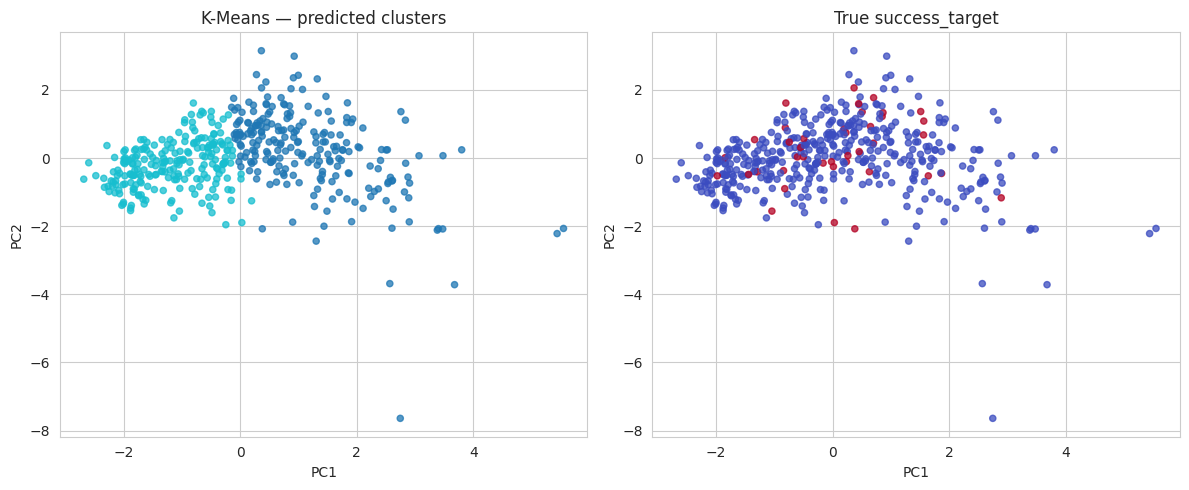

In [7]:
km = KMeans(n_clusters=2, n_init=20, random_state=RANDOM_STATE)
labels_km = km.fit_predict(X)
evaluate_clustering("K-Means (k=2)", labels_km, X, y, results)
plot_clusters("K-Means", labels_km, y)

## 6. PAM (Partitioning Around Medoids)

Like K-Means but uses actual data points (medoids) as cluster centres and the
L1 / arbitrary distance — more robust to outliers. Requires
`scikit-learn-extra`.

In [8]:
if HAS_KMEDOIDS:
    pam = KMedoids(n_clusters=2, method="pam", random_state=RANDOM_STATE)
    labels_pam = pam.fit_predict(X)
    evaluate_clustering("PAM (k=2)", labels_pam, X, y, results)
    plot_clusters("PAM", labels_pam, y)
else:
    print("scikit-learn-extra not installed — skipping PAM.")
    print("Install with: pip install scikit-learn-extra")

scikit-learn-extra not installed — skipping PAM.
Install with: pip install scikit-learn-extra


## 7. Hierarchical clustering (Ward)

Bottom-up agglomerative clustering with Ward linkage (minimises within-cluster
variance). We cut the tree at `k=2` for the metric comparison and also plot the
dendrogram to inspect the natural cluster structure.


=== Hierarchical Ward (k=2) ===
Clusters found: 2 (noise points: 0)
Internal  | silhouette=0.1774  CH=106.91  DB=1.7428
External  | ARI=-0.0106  NMI=0.0017  FMI=0.6677
          | homogeneity=0.0027  completeness=0.0012  V=0.0017
Confusion matrix (rows: success_target, cols: cluster):
cluster    0    1
true             
0        261  151
1         28   12


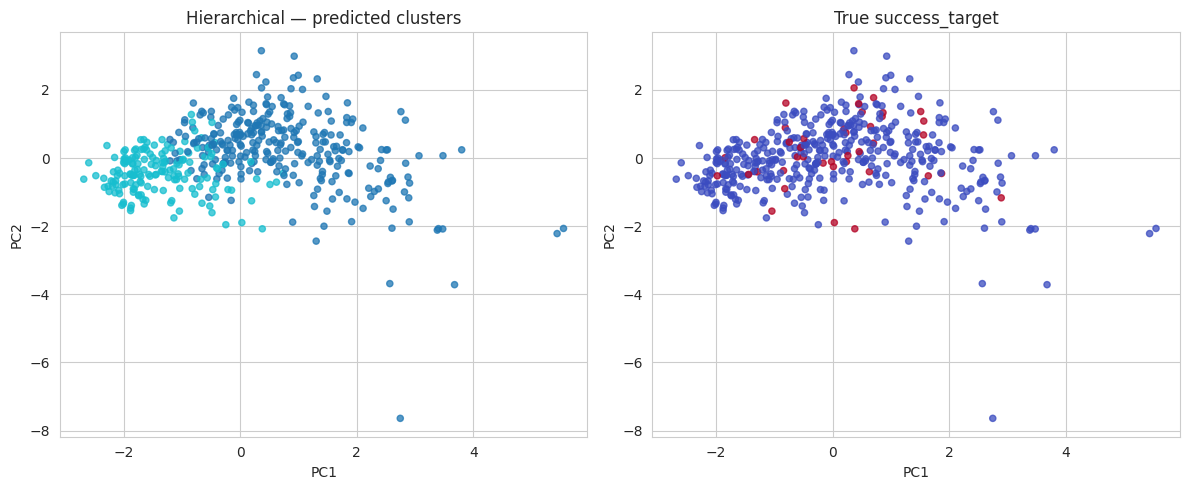

In [9]:
hc = AgglomerativeClustering(n_clusters=2, linkage="ward")
labels_hc = hc.fit_predict(X)
evaluate_clustering("Hierarchical Ward (k=2)", labels_hc, X, y, results)
plot_clusters("Hierarchical", labels_hc, y)

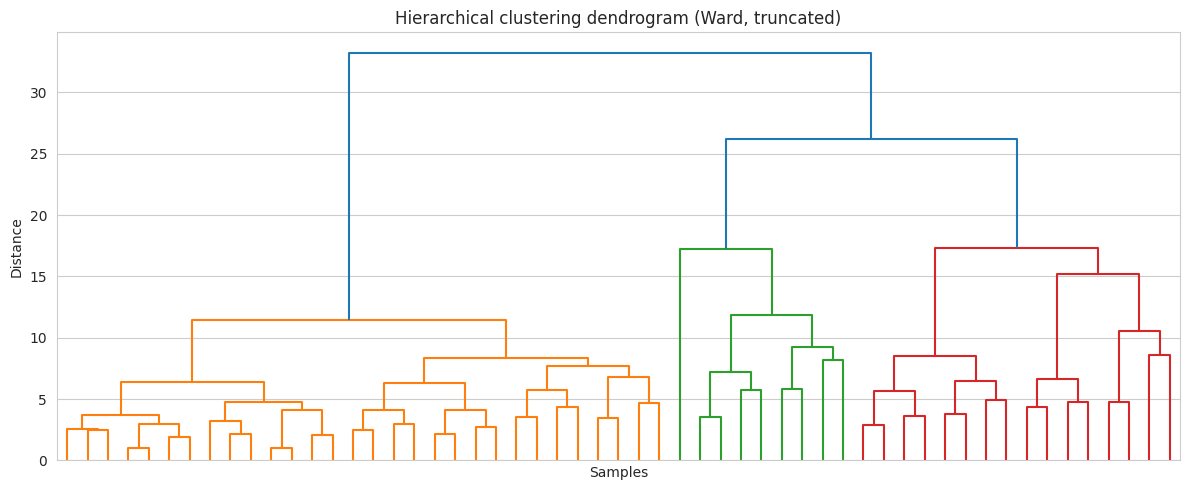

In [10]:
Z = linkage(X, method="ward")
plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode="level", p=5, no_labels=True)
plt.title("Hierarchical clustering dendrogram (Ward, truncated)")
plt.xlabel("Samples"); plt.ylabel("Distance")
plt.tight_layout()
plt.show()

## 8. Density clustering (HDBSCAN / OPTICS)

Density-based methods find clusters of arbitrary shape and label sparse regions
as noise (`-1`). We don't pre-specify `k`; the algorithm decides. HDBSCAN is
the modern choice — robust to varying densities. If `hdbscan` isn't available,
we fall back to scikit-learn's OPTICS.


=== HDBSCAN ===
Clusters found: 4 (noise points: 303)
Internal  | silhouette=0.2225  CH=44.24  DB=1.4079
External  | ARI=0.0919  NMI=0.0406  FMI=0.6703
          | homogeneity=0.0935  completeness=0.0260  V=0.0406
Confusion matrix (rows: success_target, cols: cluster):
cluster   -1   0   1   2   3
true                        
0        287  27  25  33  40
1         16   1   1   9  13


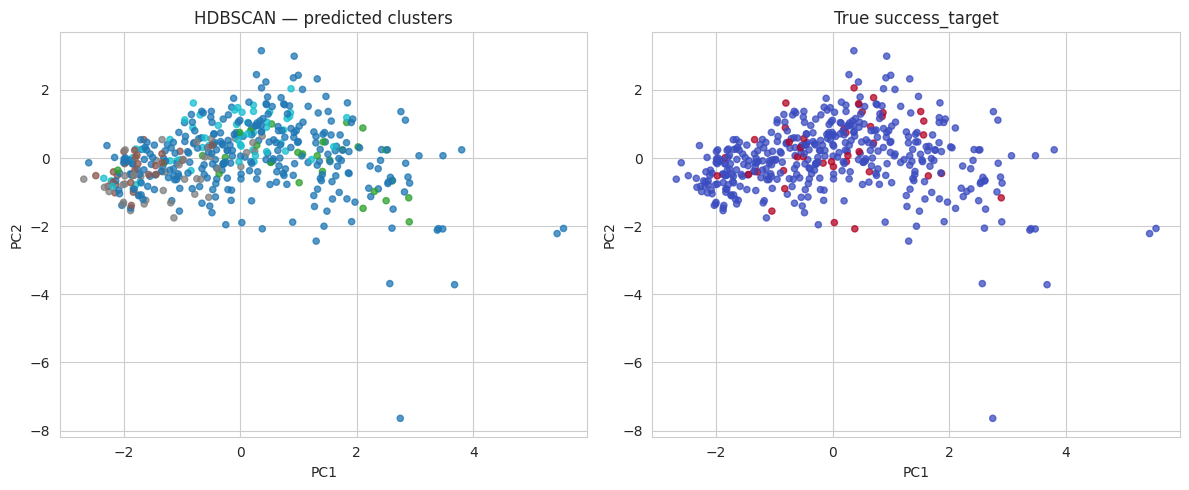

In [11]:
if HAS_HDBSCAN:
    hdb = hdbscan.HDBSCAN(min_cluster_size=20, min_samples=5)
    labels_hdb = hdb.fit_predict(X)
    evaluate_clustering("HDBSCAN", labels_hdb, X, y, results)
    plot_clusters("HDBSCAN", labels_hdb, y)
else:
    print("hdbscan not installed — falling back to OPTICS.")
    opt = OPTICS(min_samples=10)
    labels_opt = opt.fit_predict(X)
    evaluate_clustering("OPTICS", labels_opt, X, y, results)
    plot_clusters("OPTICS", labels_opt, y)

## 9. DBSCAN

Classical density clustering with two hyperparameters: `eps` (neighbourhood
radius) and `min_samples`. We pick `eps` from the elbow of the k-distance plot
(rule of thumb: `k = min_samples`).

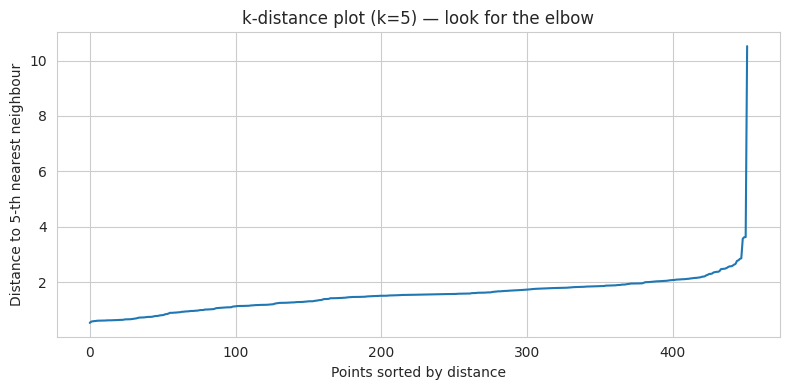

Using eps = 2.0998


In [12]:
min_samples = 5
nn = NearestNeighbors(n_neighbors=min_samples)
nn.fit(X)
d, _ = nn.kneighbors(X)
d_sorted = np.sort(d[:, -1])

plt.figure(figsize=(8, 4))
plt.plot(d_sorted)
plt.title(f"k-distance plot (k={min_samples}) — look for the elbow")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"Distance to {min_samples}-th nearest neighbour")
plt.tight_layout()
plt.show()

# Heuristic eps — 90th percentile of the k-distance. Adjust by eye from the plot above.
eps = float(np.percentile(d_sorted, 90))
print(f"Using eps = {eps:.4f}")


=== DBSCAN (eps=2.100) ===
Clusters found: 1 (noise points: 21)
Internal  | silhouette=nan  CH=nan  DB=nan
External  | ARI=-0.0258  NMI=0.0024  FMI=0.8707
          | homogeneity=0.0020  completeness=0.0032  V=0.0024
Confusion matrix (rows: success_target, cols: cluster):
cluster  -1    0
true            
0        20  392
1         1   39


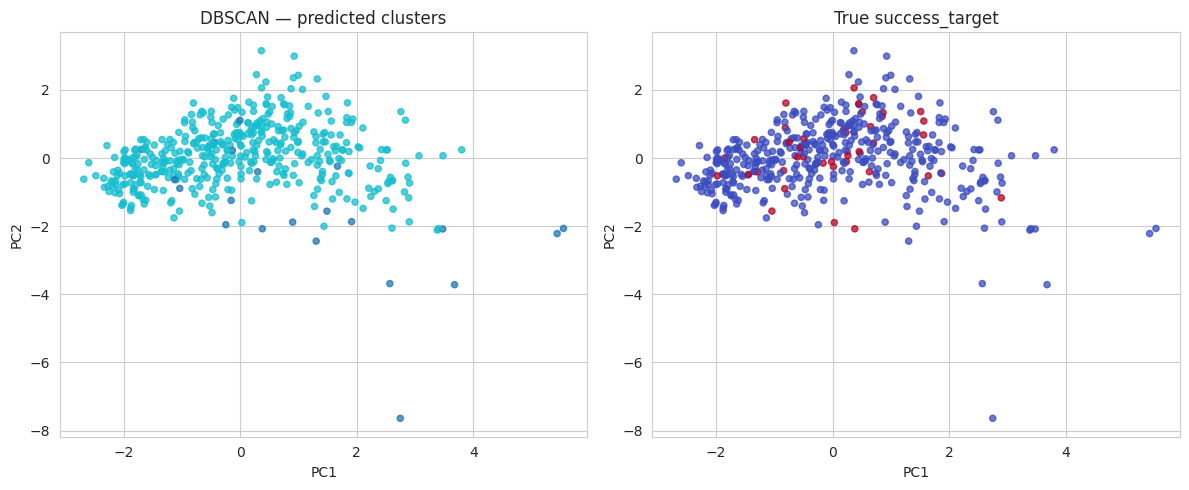

In [13]:
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
labels_db = dbscan.fit_predict(X)
evaluate_clustering(f"DBSCAN (eps={eps:.3f})", labels_db, X, y, results)
plot_clusters("DBSCAN", labels_db, y)

## 10. Fuzzy C-Means

Soft clustering: every point has a degree of membership in each cluster. We
take the argmax membership as the hard label for the external metrics, and
also report the Fuzzy Partition Coefficient (FPC ∈ [1/c, 1]; higher = crisper
partition).

Fuzzy Partition Coefficient (FPC): 0.5585

=== Fuzzy C-Means (c=2) ===
Clusters found: 2 (noise points: 0)
Internal  | silhouette=0.2118  CH=128.68  DB=1.7287
External  | ARI=-0.0005  NMI=0.0020  FMI=0.6466
          | homogeneity=0.0032  completeness=0.0014  V=0.0020
Confusion matrix (rows: success_target, cols: cluster):
cluster    0    1
true             
0        207  205
1         17   23


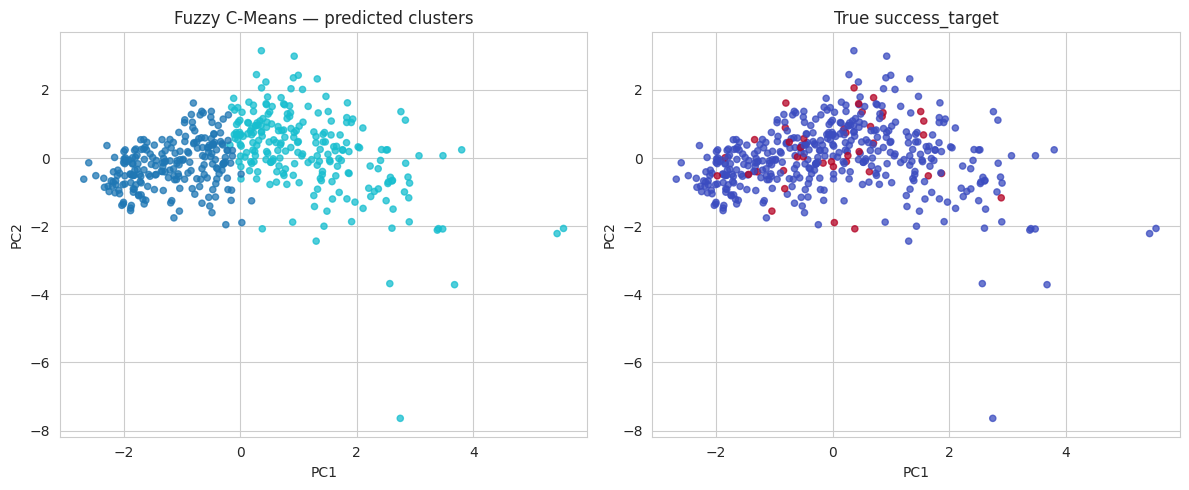

In [14]:
if HAS_SKFUZZY:
    # skfuzzy expects features-by-samples
    cntr, u, u0, d_cm, jm, p_iter, fpc = fuzz.cluster.cmeans(
        X.T, c=2, m=2.0, error=0.005, maxiter=1000, init=None, seed=RANDOM_STATE
    )
    labels_cm = np.argmax(u, axis=0)
    print(f"Fuzzy Partition Coefficient (FPC): {fpc:.4f}")
    evaluate_clustering("Fuzzy C-Means (c=2)", labels_cm, X, y, results)
    plot_clusters("Fuzzy C-Means", labels_cm, y)
else:
    print("scikit-fuzzy not installed — skipping Fuzzy C-Means.")
    print("Install with: pip install scikit-fuzzy")

## 11. Summary

External metrics (ARI, NMI, FMI, V-measure) are the ones to read if the
question is *"does clustering recover the two `success_target` groups?"*.
Internal metrics (silhouette, CH, DB) describe geometric quality regardless of
labels — useful for sanity-checking that the algorithm actually found
structure.

In [15]:
results_df = pd.DataFrame(results).sort_values("ARI", ascending=False).reset_index(drop=True)
results_df

,algorithm,n_clusters,n_noise,silhouette,calinski_harabasz,davies_bouldin,ARI,NMI,FMI,homogeneity,completeness,v_measure
0,HDBSCAN,4,303,0.222502,44.236753,1.407922,0.091901,0.040646,0.670251,0.093501,0.025967,0.040646
1,K-Means (k=2),2,0,0.212140,128.700176,1.730739,-0.000011,0.002209,0.646701,0.003665,0.001581,0.002209
2,Fuzzy C-Means (c=2),2,0,0.211787,128.678988,1.728718,-0.000456,0.001957,0.646554,0.003247,0.001401,0.001957
3,Hierarchical Ward (k=2),2,0,0.177387,106.911392,1.742837,-0.010611,0.001665,0.667721,0.002653,0.001214,0.001665
4,DBSCAN (eps=2.100),1,21,NaN,NaN,NaN,-0.025785,0.002437,0.870726,0.001984,0.003157,0.002437


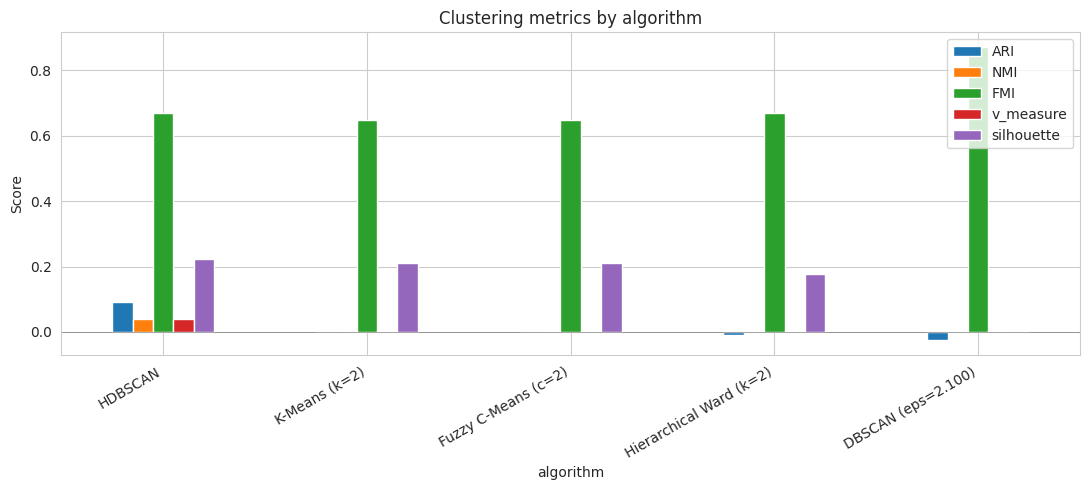

In [16]:
metrics_to_plot = ["ARI", "NMI", "FMI", "v_measure", "silhouette"]
plot_df = results_df.set_index("algorithm")[metrics_to_plot]
ax = plot_df.plot(kind="bar", figsize=(11, 5))
ax.set_title("Clustering metrics by algorithm")
ax.set_ylabel("Score")
ax.axhline(0, color="grey", lw=0.5)
plt.xticks(rotation=30, ha="right")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

### Interpretation guide

- **ARI close to 0** → the partition is no better than a random one at
  matching `success_target`. ARI can be slightly negative.
- **ARI close to 1** → the partition essentially recovers `success_target`.
- **NMI / V-measure** are also normalised; same intuition.
- **Silhouette in [-1, 1]**: values near 0 mean clusters overlap heavily.
  Negative means points are likely assigned to the wrong cluster.
- **Davies-Bouldin**: lower is better (0 is ideal).
- **DBSCAN / HDBSCAN noise**: a large noise count plus a single dense cluster
  usually means the chosen density parameters are too strict (or the geometry
  has no clear density gap).